In [ ]:
from keras.datasets import mnist

In [ ]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

11490434/11490434 [==============================] - 1s 0us/step


In [ ]:
train_images.shape

(60000, 28, 28)

In [ ]:
train_labels.shape

(60000,)

In [ ]:
test_images.shape

(10000, 28, 28)

In [ ]:
test_labels.shape

(10000,)

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
# running this once shows the plts in gray scale as default
# https://stackoverflow.com/questions/3823752/display-image-as-grayscale-using-matplotlib
plt.gray()

<Figure size 432x288 with 0 Axes>

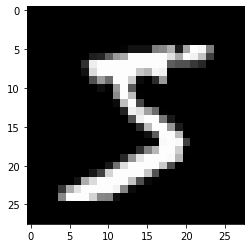

In [ ]:
# if we do run the plt.gray() ... below code would have shown a color image
plt.imshow(train_images[0])

In [ ]:
train_labels[0]

5

In [ ]:
from keras import models

In [ ]:
from keras import layers

In [ ]:
model_mlp = models.Sequential()

In [ ]:
model_mlp.add(layers.Dense(512, activation='relu', input_shape=(28*28,)))

In [ ]:
model_mlp.add(layers.Dense(10, activation='softmax'))

In [ ]:
model_mlp.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 512)               401920    
                                                                 
 dense_1 (Dense)             (None, 10)                5130      
                                                                 
Total params: 407,050
Trainable params: 407,050
Non-trainable params: 0
_________________________________________________________________


In [ ]:
model_mlp.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
train_images.shape

(60000, 28, 28)

In [ ]:
train_images_mlp = train_images.reshape(60000, 28*28)

In [ ]:
train_images_mlp.shape

(60000, 784)

In [ ]:
# type is an int
# chose a non-zero value element ... somewhere in the middle of the column vector
type(train_images_mlp[0][350])

numpy.uint8

In [ ]:
train_images_mlp[0][350]

70

In [ ]:
train_images_mlp = train_images_mlp.astype('float32') / 255

In [ ]:
# type has changed to float
type(train_images_mlp[0][350])

numpy.float32

In [ ]:
train_images_mlp[0][350]

0.27450982

In [ ]:
70/255

0.27450980392156865

In [ ]:
test_images_mlp = test_images.reshape(10000,28*28)

In [ ]:
test_images_mlp = test_images_mlp.astype('float32') / 255

In [ ]:
train_labels[0]

5

In [ ]:
from keras.utils import to_categorical

In [ ]:
train_labels_mlp = to_categorical(train_labels)

In [ ]:
train_labels_mlp[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.], dtype=float32)

In [ ]:
test_labels_mlp = to_categorical(test_labels)

In [ ]:
model_mlp.fit(train_images_mlp, train_labels_mlp, epochs = 5, batch_size = 120)

Epoch 1/5
500/500 [==============================] - 4s 8ms/step - loss: 0.0288 - accuracy: 0.9912
Epoch 2/5
500/500 [==============================] - 4s 8ms/step - loss: 0.0215 - accuracy: 0.9936
Epoch 3/5
500/500 [==============================] - 4s 8ms/step - loss: 0.0168 - accuracy: 0.9948
Epoch 4/5
500/500 [==============================] - 4s 8ms/step - loss: 0.0132 - accuracy: 0.9963
Epoch 5/5
500/500 [==============================] - 4s 8ms/step - loss: 0.0103 - accuracy: 0.9972


In [ ]:
test_loss_mlp, test_acc_mlp = model_mlp.evaluate(test_images_mlp, test_labels_mlp)

10000/10000 [==============================] - 1s 56us/step


In [ ]:
print('test accuracy:', (test_acc_mlp*100))

test accuracy: 98.01999926567078


In [ ]:
from keras import models

In [ ]:
from keras import layers

In [ ]:
model_cnn = models.Sequential()

In [ ]:
model_cnn.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))

In [ ]:
model_cnn.add(layers.MaxPooling2D(2,2))

In [ ]:
model_cnn.add(layers.Conv2D(64, (3,3), activation = 'relu'))

In [ ]:
model_cnn.add(layers.MaxPooling2D(2,2))

In [ ]:
model_cnn.add(layers.Conv2D(64, (3,3), activation='relu'))

In [ ]:
model_cnn.add(layers.Flatten())

In [ ]:
model_cnn.add(layers.Dense(64, activation = 'relu'))

In [ ]:
model_cnn.add(layers.Dense(10, activation = 'softmax'))

In [ ]:
model_cnn.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 26, 26, 32)        320       
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 13, 13, 32)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 11, 11, 64)        18496     
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 5, 5, 64)          0         
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 3, 3, 64)          36928     
_________________________________________________________________
flatten_1 (Flatten)          (None, 576)               0         
_________________________________________________________________
dense_3 (Dense)              (None, 64)               

In [ ]:
train_images.shape

(60000, 28, 28)

In [ ]:
train_images_cnn = train_images.reshape(60000, 28, 28, 1)

In [ ]:
train_images_cnn.shape

(60000, 28, 28, 1)

In [ ]:
train_images_cnn = train_images_cnn.astype('float32') / 255

In [ ]:
test_images_cnn = test_images.reshape(10000, 28, 28, 1)

In [ ]:
test_images_cnn = test_images_cnn.astype('float32') / 255

In [ ]:
from keras.utils import to_categorical

In [ ]:
train_labels_cnn = to_categorical(train_labels)

In [ ]:
test_labels_cnn = to_categorical(test_labels)

In [ ]:
model_cnn.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
model_cnn.fit(train_images_cnn, train_labels_cnn, epochs = 5, batch_size = 60)

Epoch 1/5
60000/60000 [==============================] - 38s 636us/step - loss: 0.1731 - accuracy: 0.9459
Epoch 2/5
60000/60000 [==============================] - 38s 639us/step - loss: 0.0477 - accuracy: 0.9853
Epoch 3/5
60000/60000 [==============================] - 39s 647us/step - loss: 0.0327 - accuracy: 0.9898
Epoch 4/5
60000/60000 [==============================] - 40s 665us/step - loss: 0.0243 - accuracy: 0.9925
Epoch 5/5
60000/60000 [==============================] - 39s 645us/step - loss: 0.0198 - accuracy: 0.9941


In [ ]:
test_loss_cnn, test_acc_cnn = model_cnn.evaluate(test_images_cnn, test_labels_cnn)

10000/10000 [==============================] - 2s 181us/step


In [ ]:
print('test accuracy:', (test_acc_cnn*100))

test accuracy: 99.26999807357788
